# Hospital Microgrid Data Exploration
This notebook performs a thorough visual exploration of the consolidated hospital microgrid dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Settings
plt.style.use('ggplot')
sns.set_palette('viridis')
os.makedirs('figures', exist_ok=True)
pd.set_option('display.max_columns', None)

## Section 1 — Dataset Overview

In [2]:
# Load the consolidated master dataset generated by the preprocessing pipeline.
# The notebook lives in the notebooks folder, so we use a relative path to reach the data directory.
df = pd.read_csv('../data/master_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print(f'Shape: {df.shape}')
print('\nColumn Dtypes:')
print(df.dtypes)
display(df.head())

print('\nDescriptive Statistics:')
display(df.describe())

print('\nValue Counts:')
for col in ['alert_level', 'balance_status', 'season']:
    print(f'\n{col}:')
    print(df[col].value_counts())

Shape: (35039, 53)

Column Dtypes:
temperature_2m           float64
cloud_cover              float64
windspeed_10m            float64
precipitation            float64
solar_potential          float64
wind_potential           float64
is_daytime                 int64
is_weekend                 int64
season                    object
hour                     float64
net_solar_kw             float64
solar_status              object
net_wind_kw              float64
wind_status               object
grid_available_kw        float64
is_outage                  int64
event_type                object
event_id                  object
g1_running                 int64
g1_output_kw             float64
g1_fuel_pct              float64
g2_running                 int64
g2_output_kw             float64
g2_fuel_pct              float64
g3_running                 int64
g3_output_kw             float64
g3_fuel_pct              float64
g4_running                 int64
g4_output_kw             float64
g4_fuel_

,temperature_2m,cloud_cover,windspeed_10m,precipitation,solar_potential,wind_potential,is_daytime,is_weekend,season,hour,net_solar_kw,solar_status,net_wind_kw,wind_status,grid_available_kw,is_outage,event_type,event_id,g1_running,g1_output_kw,g1_fuel_pct,g2_running,g2_output_kw,g2_fuel_pct,g3_running,g3_output_kw,g3_fuel_pct,g4_running,g4_output_kw,g4_fuel_pct,total_hospital_kw,bat_reanimation_pct,bat_bloc_pct,bat_urgences_pct,bat_neonatologie_pct,bat_dialyse_pct,bat_maternite_pct,bat_laboratoire_pct,bat_pharmacie_pct,bat_radiologie_pct,bat_general_pct,is_trading,total_supply_kw,energy_balance_kw,balance_status,avg_battery_pct,min_battery_pct,min_battery_section,total_generator_kw,any_generator_running,any_fuel_critical,renewable_fraction,alert_level
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,10.8,0.0,5.50,0.0,0.0,0.0,0,1,winter,0.0,0.0,night,0.0,normal,600.0,0,none,STABLE,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,165.702273,99.250212,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,99.250212,0,600.0,434.297727,surplus,99.850222,99.250212,reanimation,0.0,0,0,0.0,NORMAL
2022-01-01 00:30:00,10.8,0.0,5.45,0.0,0.0,0.0,0,1,winter,0.5,0.0,night,0.0,normal,600.0,0,none,STABLE,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,171.915197,100.000011,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000011,0,600.0,428.084803,surplus,100.000182,100.000011,reanimation,0.0,0,0,0.0,NORMAL
2022-01-01 01:00:00,10.8,0.0,5.40,0.0,0.0,0.0,0,1,winter,1.0,0.0,night,0.0,normal,600.0,0,none,STABLE,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,169.432599,100.000011,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000011,0,600.0,430.567401,surplus,100.000182,100.000011,reanimation,0.0,0,0,0.0,NORMAL
2022-01-01 01:30:00,10.9,0.0,6.65,0.0,0.0,0.0,0,1,winter,1.5,0.0,night,0.0,normal,600.0,0,none,STABLE,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,172.957626,100.000011,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000225,100.000011,0,600.0,427.042374,surplus,100.000182,100.000011,reanimation,0.0,0,0,0.0,NORMAL
2022-01-01 02:00:00,11.0,0.0,7.90,0.0,0.0,0.0,0,1,winter,2.0,0.0,night,0.0,normal,0.0,1,maintenance,37A65E56,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,0,0.0,100.0,168.823916,90.979495,84.536469,82.818269,89.691062,84.536469,83.892144,87.113766,91.409258,80.670519,84.536255,0,0.0,-168.823916,critical,86.018371,80.670519,radiologie,0.0,0,0,0.0,CRITICAL



Descriptive Statistics:


,temperature_2m,cloud_cover,windspeed_10m,precipitation,solar_potential,wind_potential,is_daytime,is_weekend,hour,net_solar_kw,net_wind_kw,grid_available_kw,is_outage,g1_running,g1_output_kw,g1_fuel_pct,g2_running,g2_output_kw,g2_fuel_pct,g3_running,g3_output_kw,g3_fuel_pct,g4_running,g4_output_kw,g4_fuel_pct,total_hospital_kw,bat_reanimation_pct,bat_bloc_pct,bat_urgences_pct,bat_neonatologie_pct,bat_dialyse_pct,bat_maternite_pct,bat_laboratoire_pct,bat_pharmacie_pct,bat_radiologie_pct,bat_general_pct,is_trading,total_supply_kw,energy_balance_kw,avg_battery_pct,min_battery_pct,total_generator_kw,any_generator_running,any_fuel_critical,renewable_fraction
count,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.0,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.000000,35039.0,35039.000000
mean,18.601321,45.051657,9.891980,0.034955,0.221669,0.065485,0.557778,0.287651,11.749665,23.245828,0.710087,592.342676,0.006279,0.005194,1.558264,99.966729,0.005194,1.038842,99.951380,0.002169,0.325352,99.968537,0.002169,0.216901,99.908599,259.885969,99.968645,99.946282,99.955055,99.964190,99.946282,99.944043,99.955236,99.970159,99.679609,99.631985,0.0,619.437950,359.551982,99.896149,99.592544,3.139359,0.005194,0.0,0.036468
std,4.905392,40.233715,5.085702,0.280468,0.294974,0.114689,0.496658,0.452674,6.926613,30.323595,3.455047,46.920940,0.078990,0.071884,21.565347,0.499867,0.071884,14.376898,0.697082,0.046523,6.978417,0.611798,0.046523,4.652278,1.471455,86.480305,0.531424,0.911053,0.847791,0.607334,0.911053,0.949021,0.759189,0.506102,4.162747,4.308765,0.0,43.146290,73.338438,1.255521,4.738725,44.346023,0.071884,0.0,0.047976
min,3.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.370000,0.000000,0.000000,79.170000,0.000000,0.000000,77.080000,0.000000,0.000000,54.170000,142.981123,90.977714,84.531040,82.813831,89.688525,84.531040,83.886273,87.109928,91.407427,20.000008,25.000049,0.0,0.000000,-348.419221,75.578384,20.000008,0.000000,0.000000,0.0,0.000000
25%,14.950000,3.000000,6.150000,0.000000,0.000000,0.000000,0.000000,0.000000,5.750000,0.000000,0.000000,600.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,173.116482,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000023,100.000055,0.0,600.000000,296.880414,100.000018,100.000000,0.000000,0.000000,0.0,0.000000
50%,18.900000,35.500000,8.900000,0.000000,0.015200,0.000000,1.000000,0.000000,11.500000,1.707439,0.000000,600.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,263.027857,100.000135,100.000232,100.000020,100.000155,100.000232,100.000242,100.000193,100.000129,100.000091,100.000056,0.0,601.298183,367.800630,100.000138,100.000000,0.000000,0.000000,0.0,0.004718
75%,21.950000,94.000000,13.000000,0.000000,0.438900,0.100000,1.000000,1.000000,17.500000,47.443635,0.153817,600.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000,350.299407,100.000135,100.000232,100.000020,100.000155,100.000232,100.000242,100.000193,100.000129,100.000131,100.000127,0.0,648.619558,427.005688,100.000152,100.000020,0.000000,0.000000,0.0,0.074854
max,37.400000,100.000000,56.000000,18.600000,1.000000,1.000000,1.000000,1.000000,23.500000,99.186198,76.146516,600.000000,1.000000,1.000000,300.000000,100.000000,1.000000,200.


Value Counts:

alert_level:
alert_level
NORMAL      34819
WARNING       200
CRITICAL       20
Name: count, dtype: int64

balance_status:
balance_status
surplus     34836
critical      181
normal         12
warning        10
Name: count, dtype: int64

season:
season
spring    8832
summer    8832
autumn    8736
winter    8639
Name: count, dtype: int64


## Section 2 — Energy Supply Over Time

C:\Users\Douae Hadad\AppData\Local\Temp\ipykernel_9808\2991118737.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_supply = df[['net_solar_kw', 'net_wind_kw', 'grid_available_kw']].resample('M').mean()


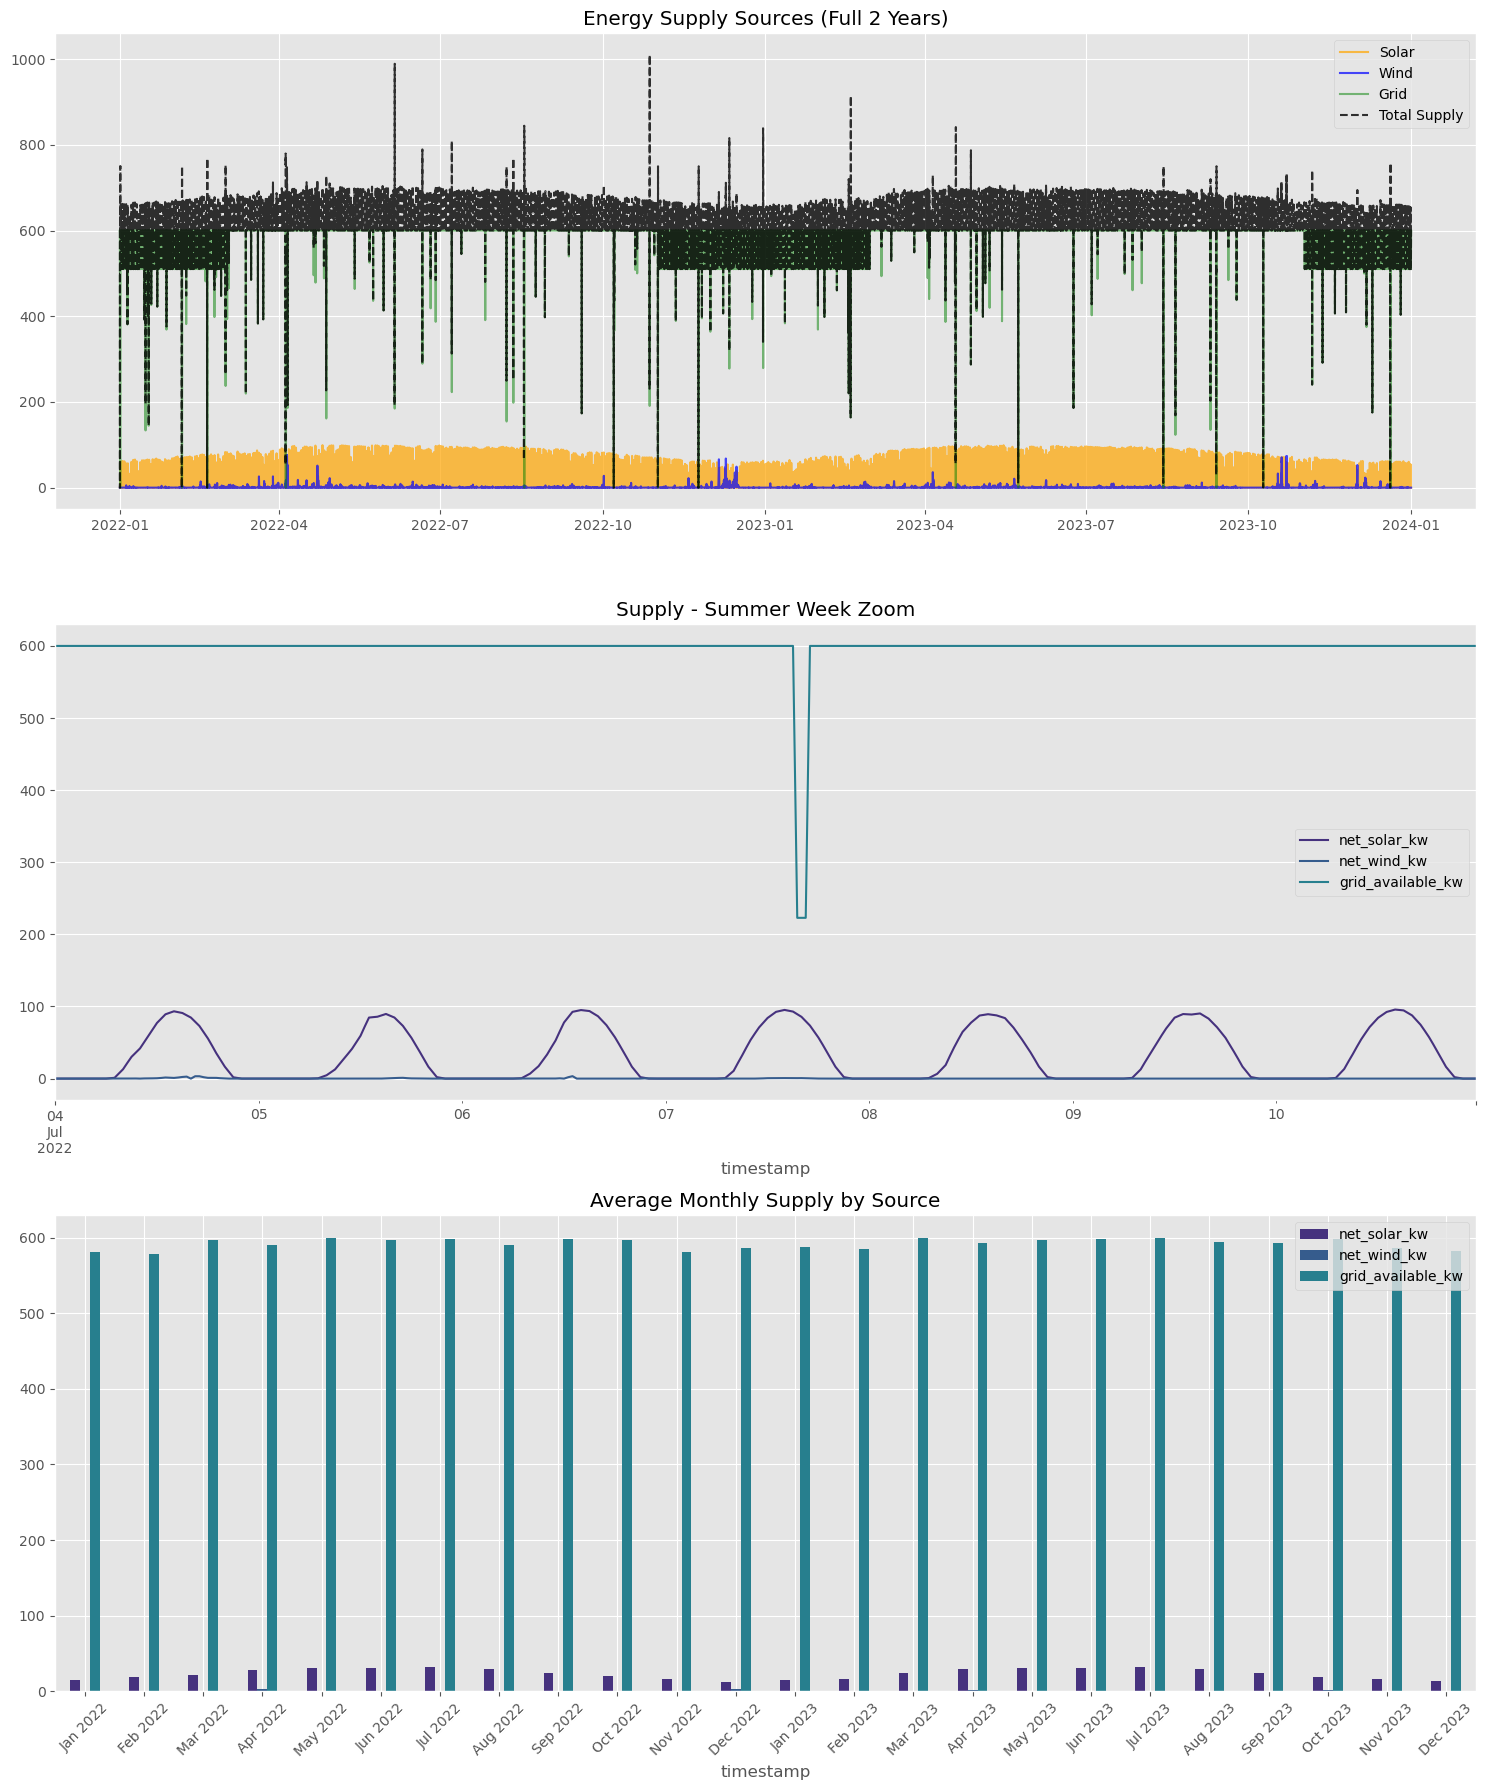

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=False)

# Plot 1: Full 2 years
axes[0].plot(df.index, df['net_solar_kw'], color='orange', label='Solar', alpha=0.7)
axes[0].plot(df.index, df['net_wind_kw'], color='blue', label='Wind', alpha=0.7)
axes[0].plot(df.index, df['grid_available_kw'], color='green', label='Grid', alpha=0.5)
axes[0].plot(df.index, df['total_supply_kw'], color='black', linestyle='--', label='Total Supply', alpha=0.8)
axes[0].set_title('Energy Supply Sources (Full 2 Years)')
axes[0].legend()

# Plot 2: Summer vs Winter Week
summer_week = df.loc['2022-07-04':'2022-07-10']
winter_week = df.loc['2023-01-02':'2023-01-08']

ax2 = plt.subplot(3, 1, 2)
summer_week[['net_solar_kw', 'net_wind_kw', 'grid_available_kw']].plot(ax=ax2, title='Summer Week (July 2022)')
plt.title('Supply - Summer Week Zoom')

# Plot 3: Monthly Bar
monthly_supply = df[['net_solar_kw', 'net_wind_kw', 'grid_available_kw']].resample('M').mean()
monthly_supply.index = monthly_supply.index.strftime('%b %Y')
monthly_supply.plot(kind='bar', ax=axes[2], stacked=False)
axes[2].set_title('Average Monthly Supply by Source')
axes[2].set_xticklabels(monthly_supply.index, rotation=45)

plt.tight_layout()
plt.savefig('figures/energy_supply.png')
plt.show()

## Section 3 — Hospital Demand

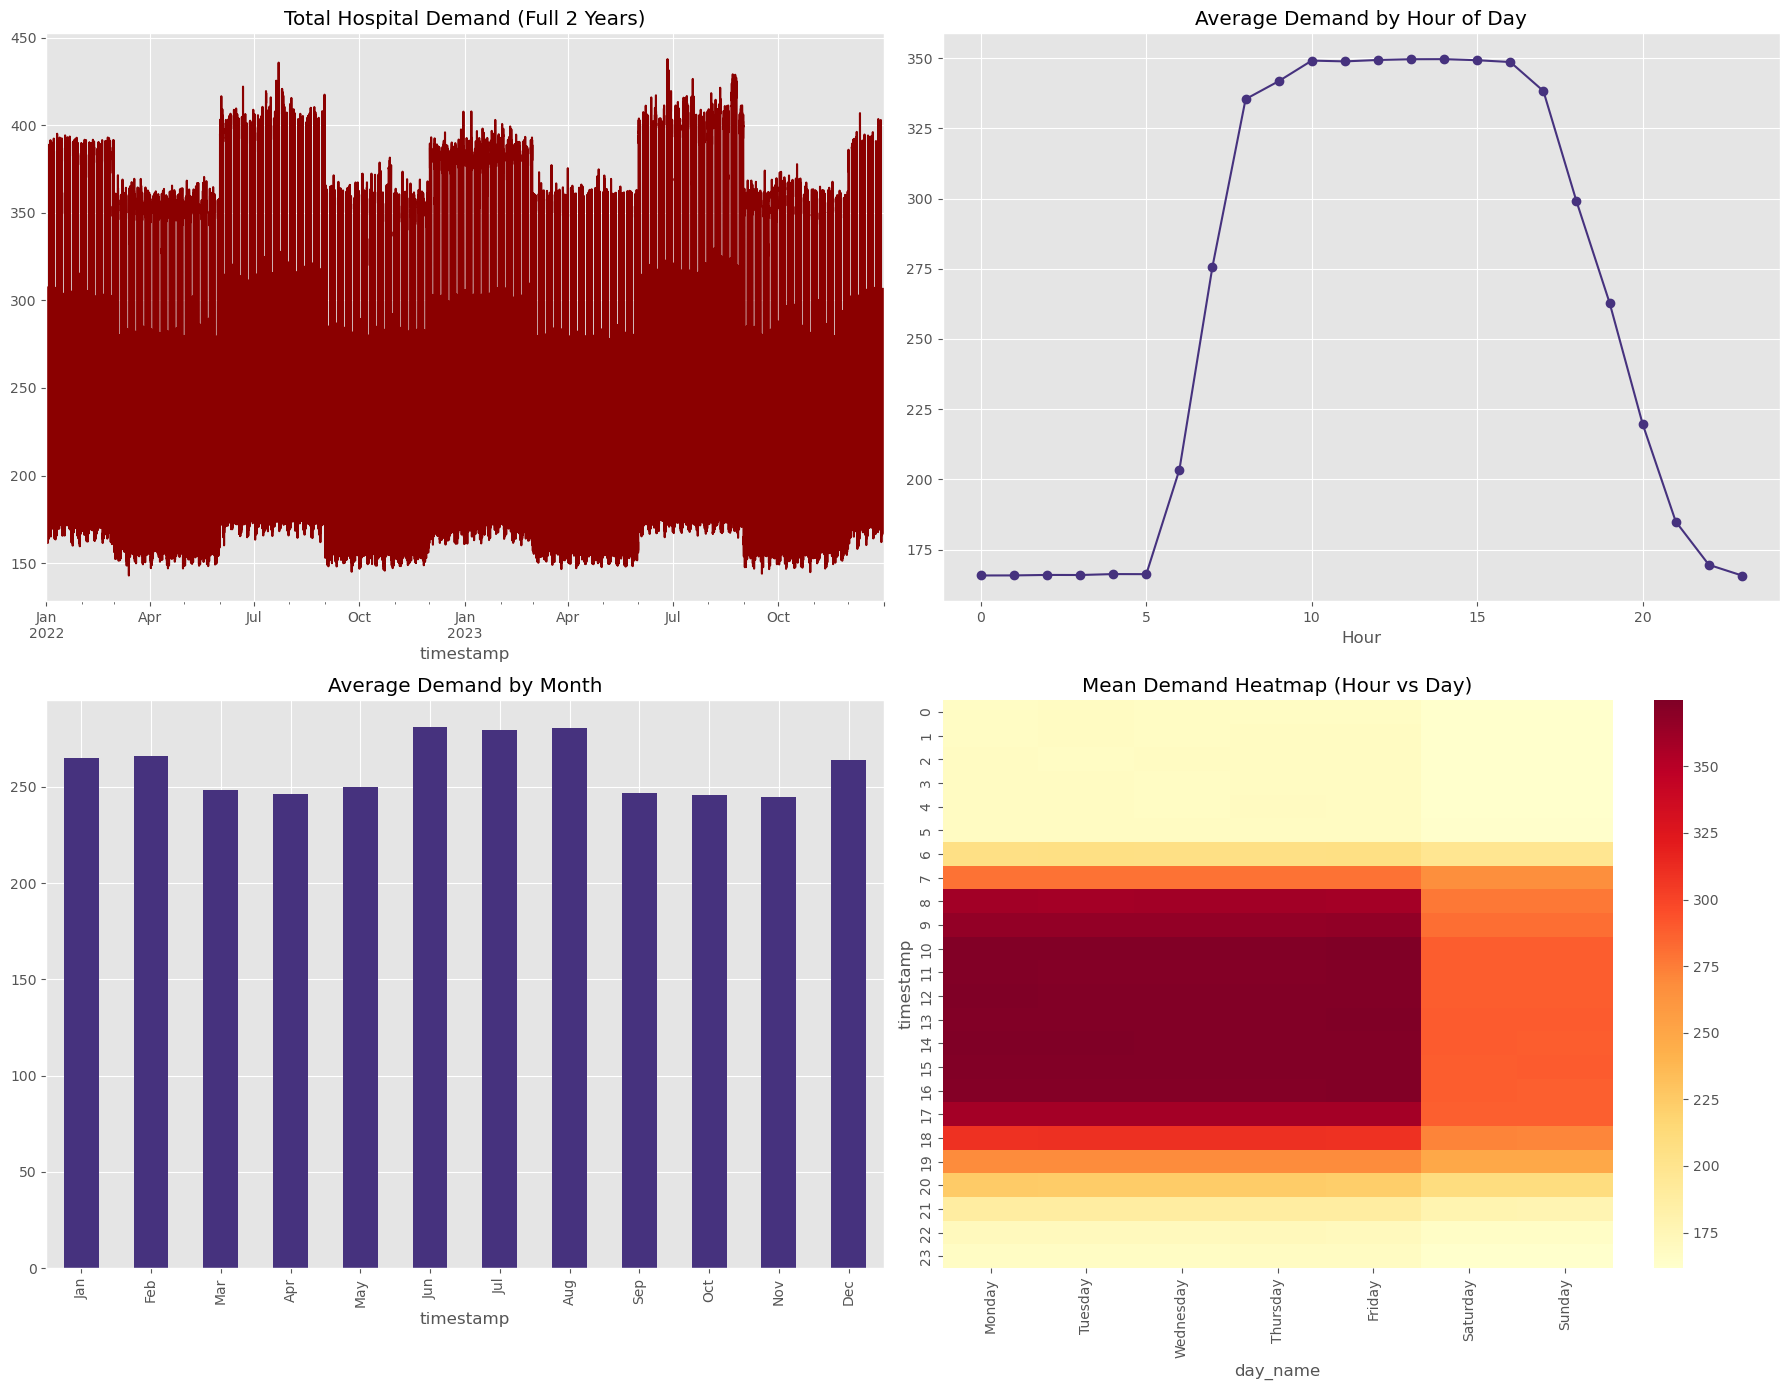

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. 2 Years
df['total_hospital_kw'].plot(ax=axes[0,0], title='Total Hospital Demand (Full 2 Years)', color='darkred')

# 2. Hourly Cycle
df.groupby(df.index.hour)['total_hospital_kw'].mean().plot(ax=axes[0,1], title='Average Demand by Hour of Day', marker='o')
axes[0,1].set_xlabel('Hour')

# 3. Monthly Cycle
df.groupby(df.index.month)['total_hospital_kw'].mean().plot(kind='bar', ax=axes[1,0], title='Average Demand by Month')
axes[1,0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 4. Heatmap
df['day_name'] = df.index.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.pivot_table(index=df.index.hour, columns='day_name', values='total_hospital_kw', aggfunc='mean')[days_order]
sns.heatmap(heatmap_data, ax=axes[1,1], cmap='YlOrRd', annot=False)
axes[1,1].set_title('Mean Demand Heatmap (Hour vs Day)')

plt.tight_layout()
plt.savefig('figures/hospital_demand.png')
plt.show()

## Section 4 — Energy Balance

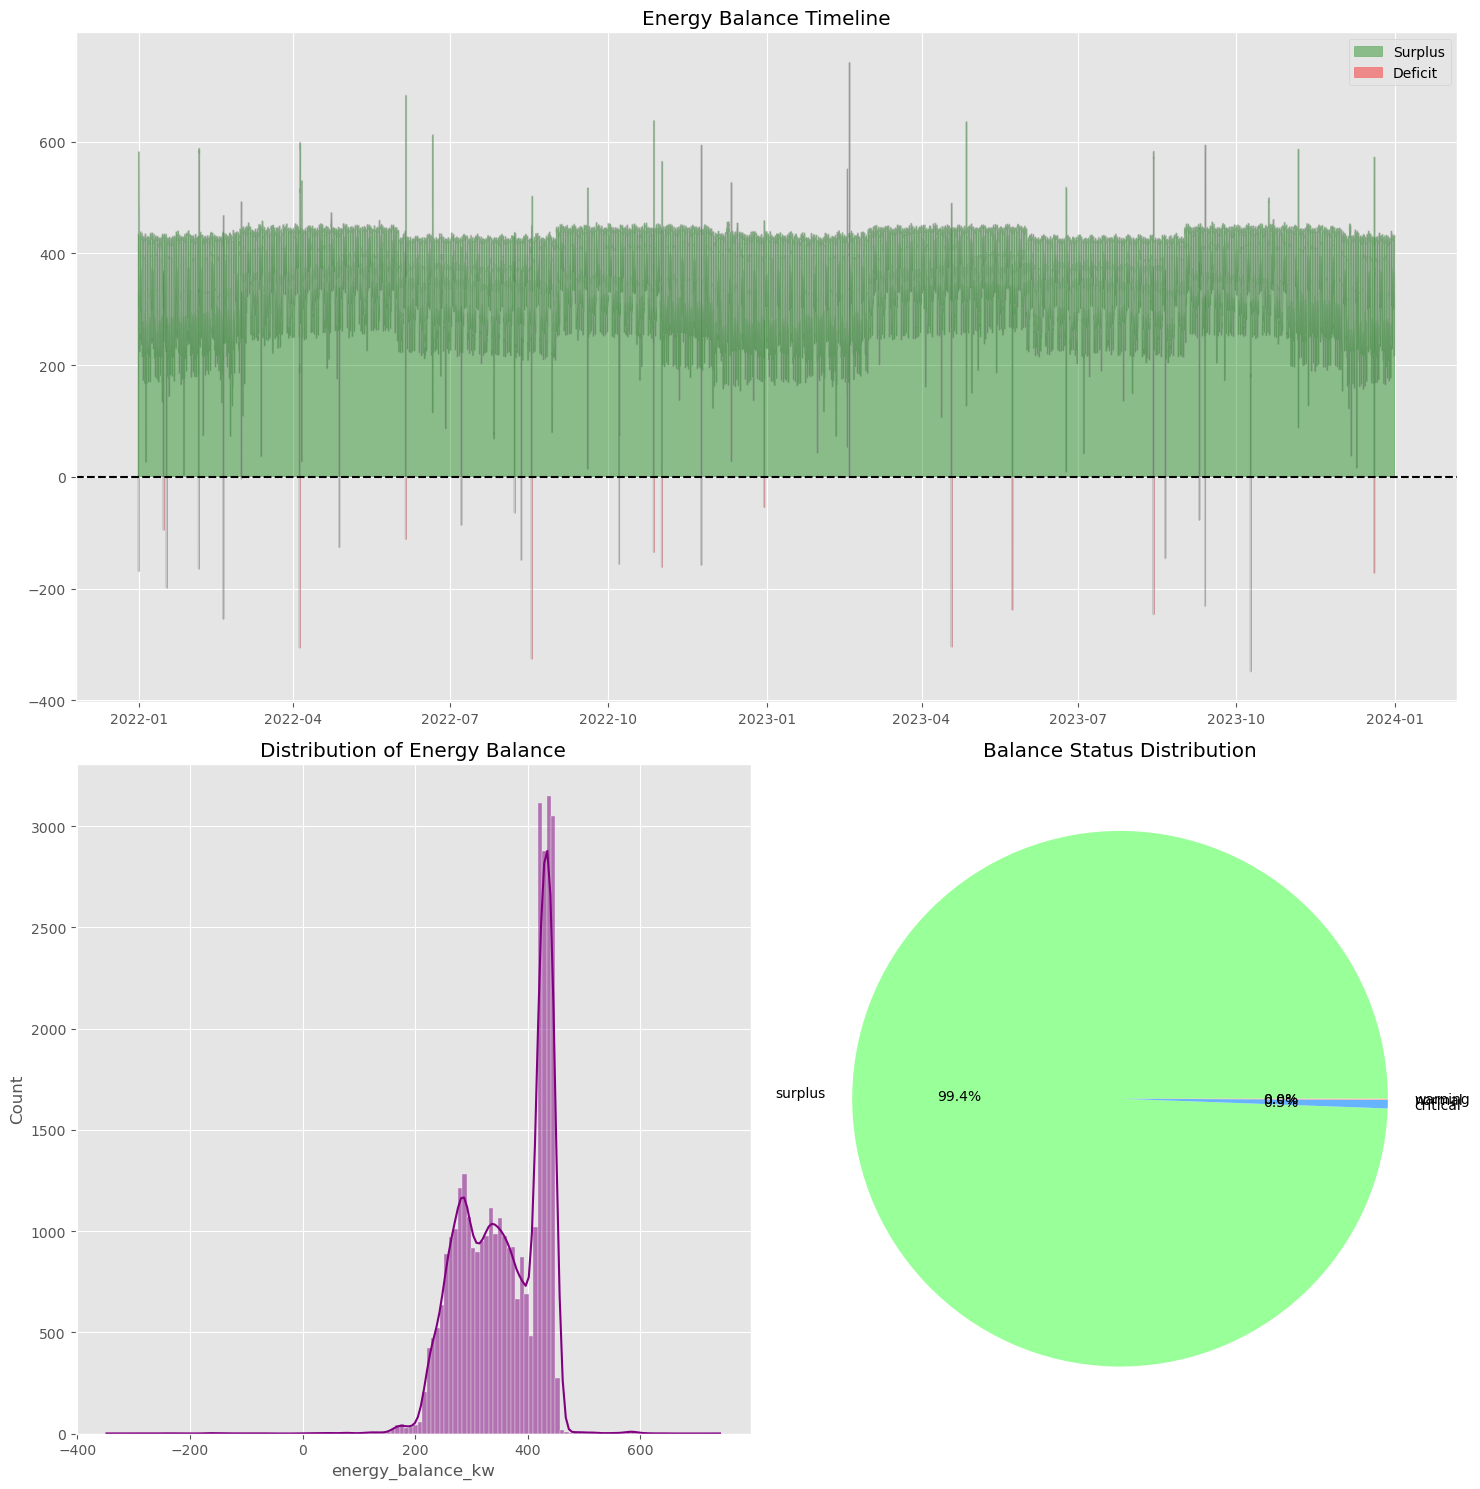

In [5]:
fig = plt.figure(figsize=(15, 15))

# 1. Timeline Area Plot
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df.index, df['energy_balance_kw'], color='gray', alpha=0.3)
ax1.fill_between(df.index, df['energy_balance_kw'], 0, where=(df['energy_balance_kw'] > 0), color='green', alpha=0.4, label='Surplus')
ax1.fill_between(df.index, df['energy_balance_kw'], 0, where=(df['energy_balance_kw'] < 0), color='red', alpha=0.4, label='Deficit')
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('Energy Balance Timeline')
ax1.legend()

# 2. Histogram
ax2 = plt.subplot(2, 2, 3)
sns.histplot(df['energy_balance_kw'], kde=True, ax=ax2, color='purple')
ax2.set_title('Distribution of Energy Balance')

# 3. Pie Chart
ax3 = plt.subplot(2, 2, 4)
df['balance_status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax3, colors=['#99ff99','#66b3ff','#ff9999','#ffcc99'])
ax3.set_title('Balance Status Distribution')
ax3.set_ylabel('')

plt.tight_layout()
plt.savefig('figures/energy_balance.png')
plt.show()

## Section 5 — Battery State of Charge

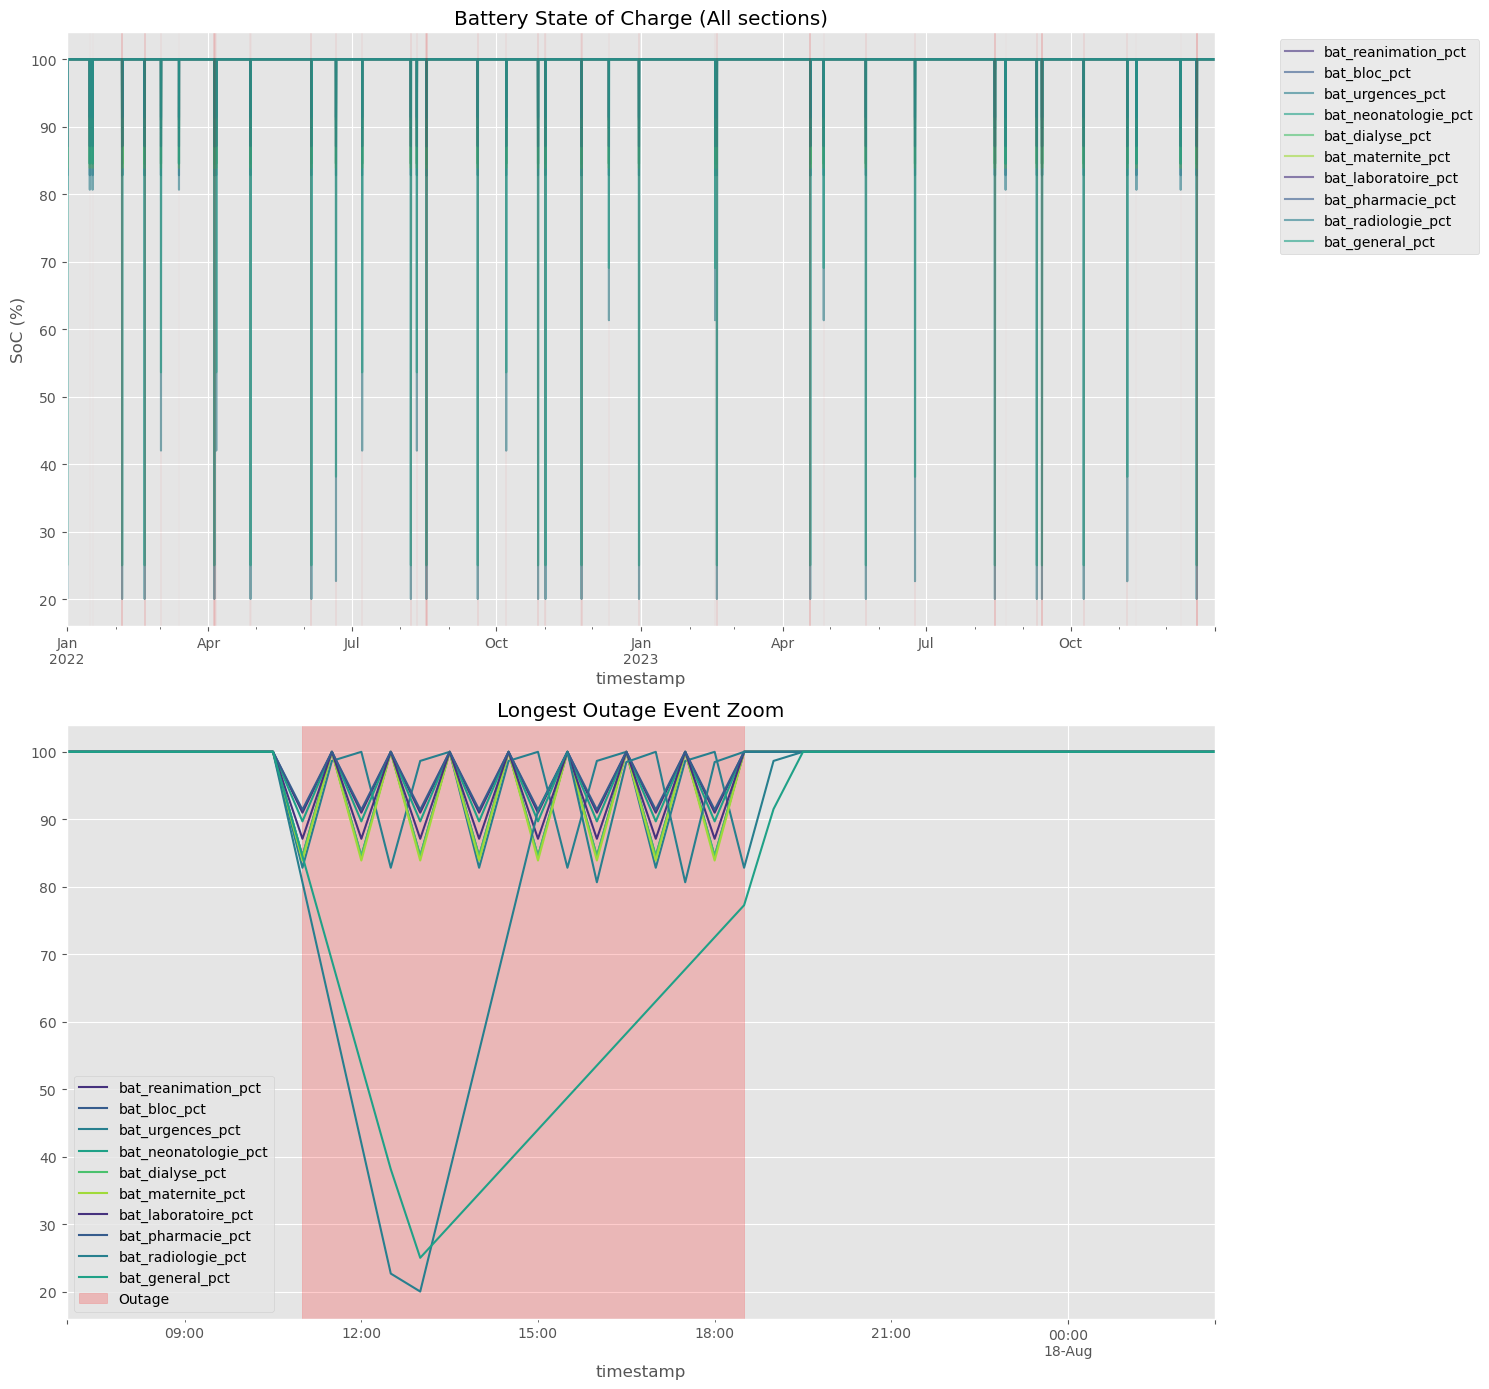

In [6]:
bat_cols = [c for c in df.columns if c.startswith('bat_') and c.endswith('_pct')]

fig, axes = plt.subplots(2, 1, figsize=(15, 14))

# 1. Full Timeline
df[bat_cols].plot(ax=axes[0], alpha=0.6)
axes[0].set_title('Battery State of Charge (All sections)')
axes[0].set_ylabel('SoC (%)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Highlight outages
outage_starts = df[df['is_outage'] == 1].index
for start in outage_starts:
    axes[0].axvline(start, color='red', alpha=0.01)

# 2. Zoom longest outage
# Find longest continuous outage
df['outage_group'] = (df['is_outage'] != df['is_outage'].shift()).cumsum()
outages = df[df['is_outage'] == 1].groupby('outage_group')
longest_group = outages.size().idxmax()
longest_outage_df = df[df['outage_group'] == longest_group]

# Buffer for zoom
zoom_start = longest_outage_df.index.min() - pd.Timedelta(hours=4)
zoom_end = longest_outage_df.index.max() + pd.Timedelta(hours=8)
df.loc[zoom_start:zoom_end, bat_cols].plot(ax=axes[1])
axes[1].axvspan(longest_outage_df.index.min(), longest_outage_df.index.max(), color='red', alpha=0.2, label='Outage')
axes[1].set_title('Longest Outage Event Zoom')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/battery_soc.png')
plt.show()

## Section 6 — Alert Levels & Anomalies

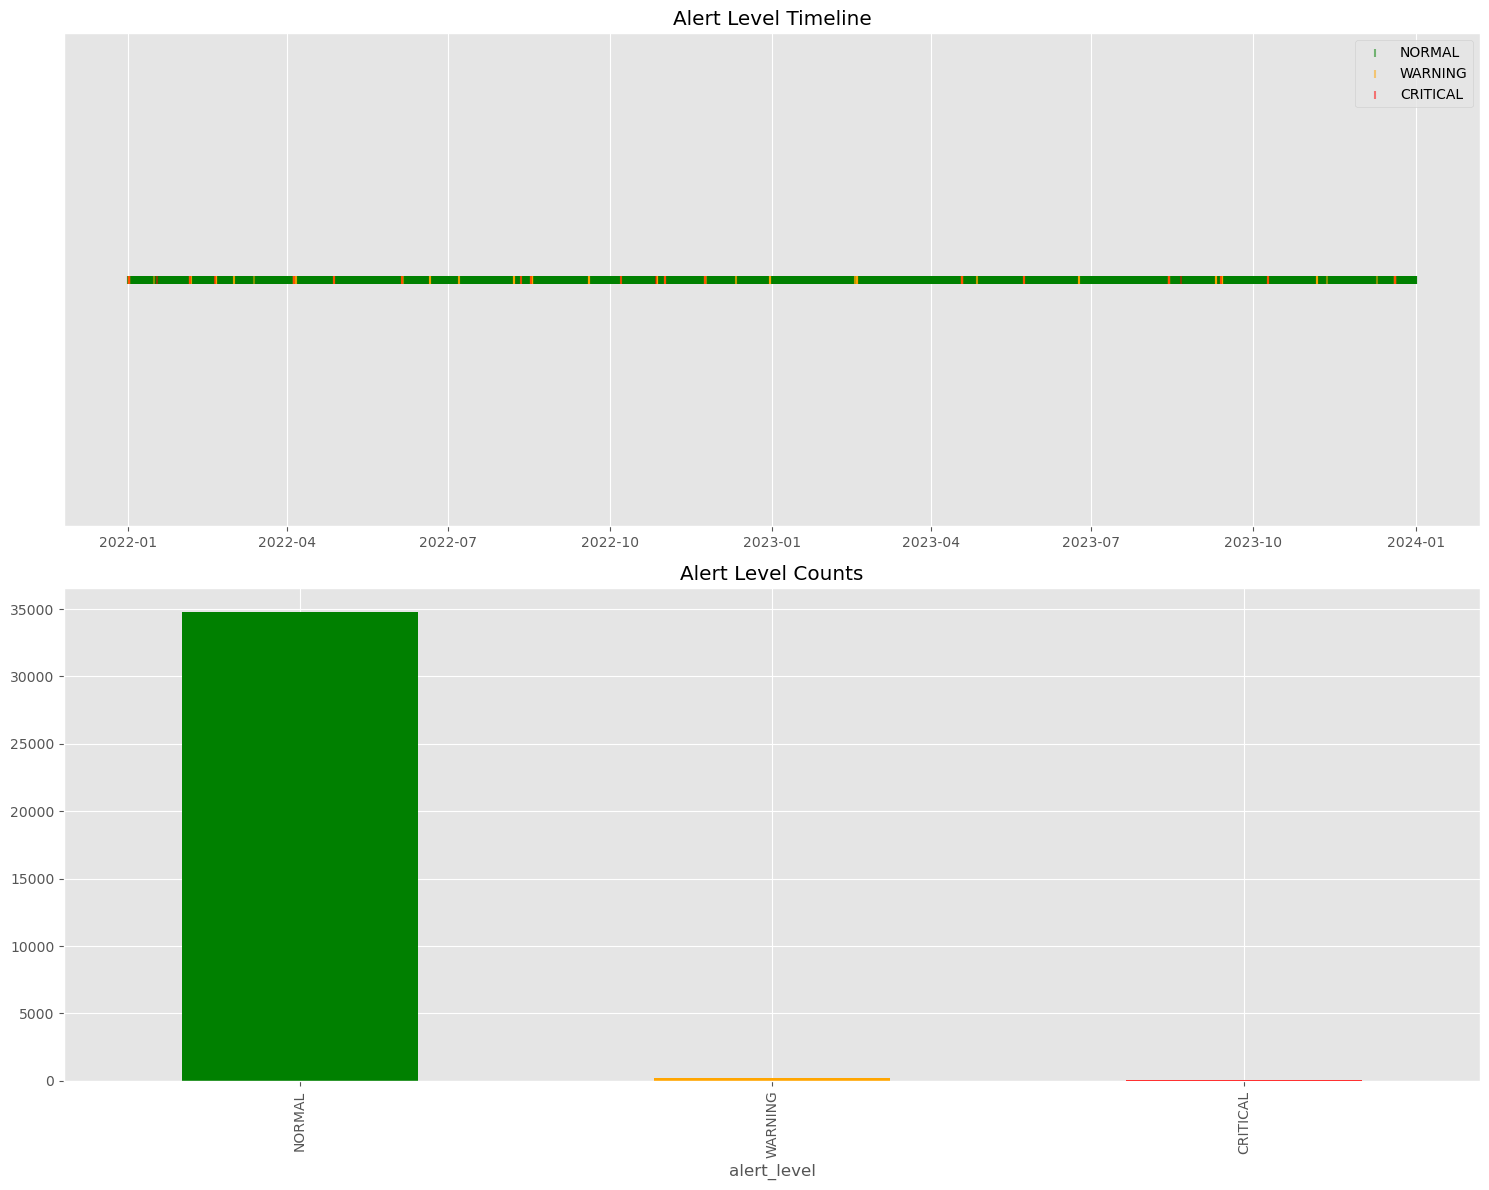

Critical Alert Timestamps:


,energy_balance_kw,min_battery_pct,min_battery_section,is_outage
timestamp,,,,
2022-01-01 02:00:00,-168.823916,80.670519,radiologie,1
2022-01-17 08:00:00,-198.282088,80.669804,radiologie,1
2022-02-05 00:30:00,-164.483265,80.669692,radiologie,1
2022-02-19 08:00:00,-254.372046,80.669348,radiologie,1
2022-04-04 15:30:00,-305.529843,80.668642,radiologie,1
2022-04-27 16:00:00,-125.886081,80.668003,radiologie,1
2022-06-05 07:30:00,-111.353869,80.667601,radiologie,1
2022-08-11 10:30:00,-148.506383,80.665940,radiologie,1
2022-08-17 11:00:00,-325.681694,80.665541,radiologie,1


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Timeline
color_map = {'NORMAL': 'green', 'WARNING': 'orange', 'CRITICAL': 'red'}
for level, color in color_map.items():
    mask = df['alert_level'] == level
    axes[0].scatter(df.index[mask], [1]*mask.sum(), color=color, label=level, marker='|', alpha=0.5)
axes[0].set_title('Alert Level Timeline')
axes[0].set_yticks([])
axes[0].legend()

# Bar Chart
df['alert_level'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('Alert Level Counts')

plt.tight_layout()
plt.savefig('figures/alerts.png')
plt.show()

print('Critical Alert Timestamps:')
critical_df = df[df['alert_level'] == 'CRITICAL'][['energy_balance_kw', 'min_battery_pct', 'min_battery_section', 'is_outage']]
display(critical_df.head(20))

## Section 7 — Correlations

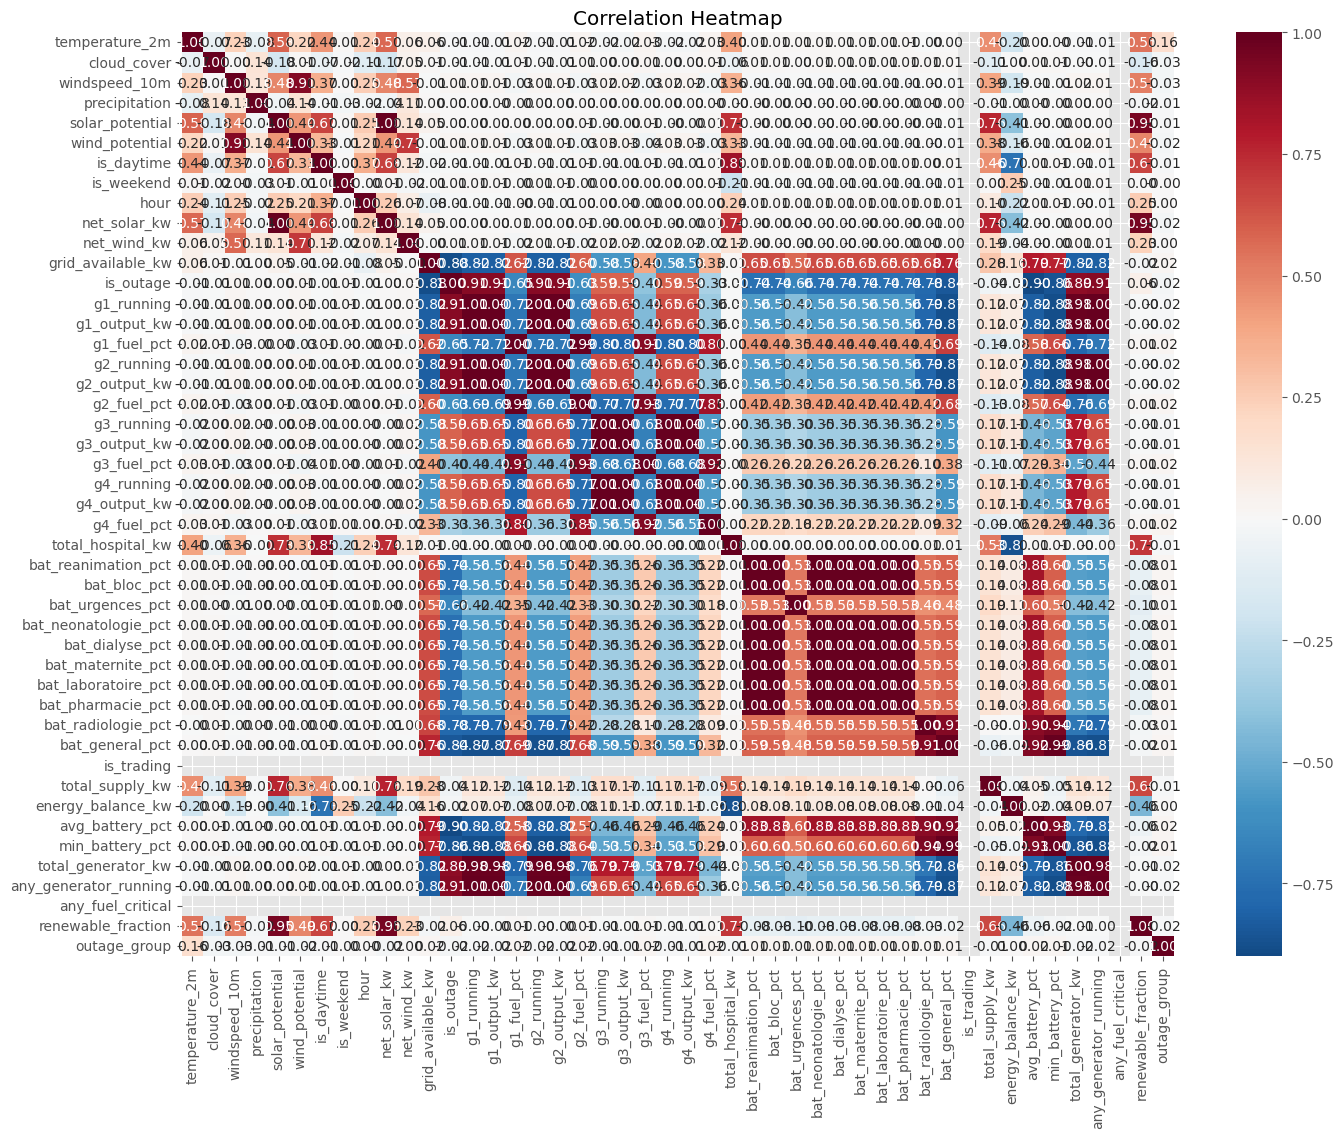

Top 10 features correlated with total_hospital_kw:
energy_balance_kw     0.866855
is_daytime            0.850969
net_solar_kw          0.737755
solar_potential       0.727931
renewable_fraction    0.717443
total_supply_kw       0.530903
temperature_2m        0.400553
windspeed_10m         0.357477
wind_potential        0.326221
hour                  0.235652
Name: total_hospital_kw, dtype: float64

Top 10 features correlated with is_outage:
g1_output_kw             0.909049
any_generator_running    0.909049
g2_running               0.909049
g1_running               0.909049
g2_output_kw             0.909049
avg_battery_pct          0.900367
total_generator_kw       0.890614
grid_available_kw        0.881785
min_battery_pct          0.857948
bat_general_pct          0.843052
Name: is_outage, dtype: float64


In [8]:
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.savefig('figures/correlations.png')
plt.show()

print('Top 10 features correlated with total_hospital_kw:')
print(corr['total_hospital_kw'].abs().sort_values(ascending=False).head(11)[1:])

print('\nTop 10 features correlated with is_outage:')
print(corr['is_outage'].abs().sort_values(ascending=False).head(11)[1:])

## Section 8 — Renewable Energy Analysis

Timesteps with Renewable Fraction > 50%: 0.02%
Timesteps with Renewable Fraction > 75%: 0.02%
Timesteps with Renewable Fraction == 100%: 0.02%


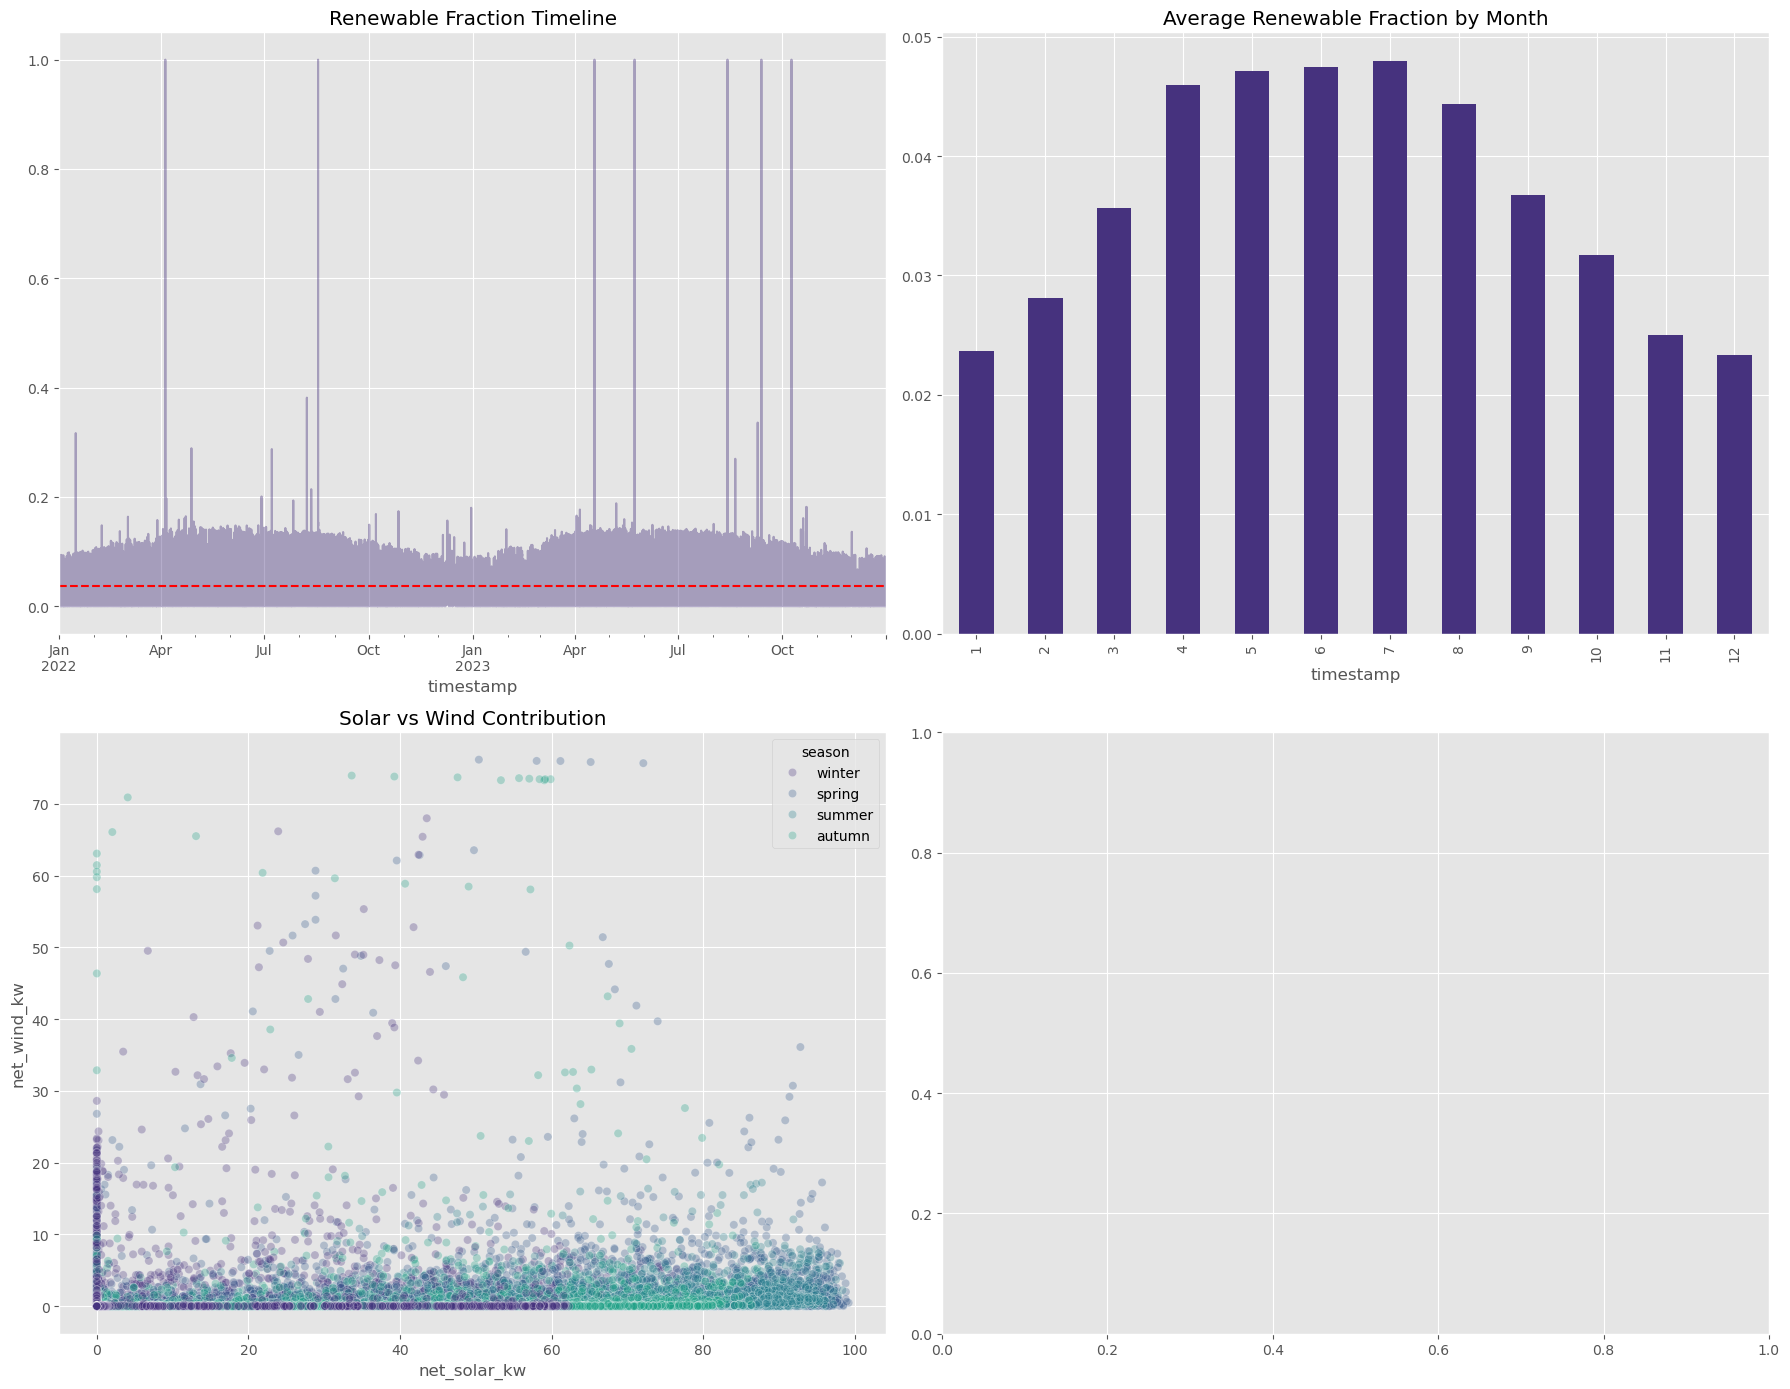

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Fraction timeline
df['renewable_fraction'].plot(ax=axes[0,0], title='Renewable Fraction Timeline', alpha=0.4)
axes[0,0].axhline(df['renewable_fraction'].mean(), color='red', linestyle='--', label='Mean')

# 2. Monthly bar
df.groupby(df.index.month)['renewable_fraction'].mean().plot(kind='bar', ax=axes[0,1], title='Average Renewable Fraction by Month')

# 3. Solar vs Wind scatter
sns.scatterplot(data=df, x='net_solar_kw', y='net_wind_kw', hue='season', ax=axes[1,0], alpha=0.3)
axes[1,0].set_title('Solar vs Wind Contribution')

# 4. Threshold Counts
total = len(df)
gt50 = (df['renewable_fraction'] > 0.5).sum() / total * 100
gt75 = (df['renewable_fraction'] > 0.75).sum() / total * 100
eq100 = (df['renewable_fraction'] >= 0.99).sum() / total * 100

print(f'Timesteps with Renewable Fraction > 50%: {gt50:.2f}%')
print(f'Timesteps with Renewable Fraction > 75%: {gt75:.2f}%')
print(f'Timesteps with Renewable Fraction == 100%: {eq100:.2f}%')

plt.tight_layout()
plt.savefig('figures/renewables.png')
plt.show()

## Section 9 — P2P Trading Events

In [10]:
trades = pd.read_csv('../data/trades/energy_trades.csv')
trades['timestamp'] = pd.to_datetime(trades['timestamp'])

if trades.empty:
    print('No trades were generated in the current dataset. Skipping trade plots.')
else:
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))

    # Timeline
    axes[0].scatter(trades['timestamp'], [1]*len(trades), color='blue', marker='x')
    axes[0].set_title('P2P Trading Event Timeline')
    axes[0].set_yticks([])

    # Donors
    trades.groupby('donor_section')['traded_kw'].sum().plot(kind='bar', ax=axes[1], title='Total Energy Donated by Section (kW-steps)')

    # Receivers
    trades.groupby('receiver_section')['traded_kw'].sum().plot(kind='bar', ax=axes[2], title='Total Energy Received by Section (kW-steps)')

    plt.tight_layout()
    plt.savefig('figures/trades.png')
    plt.show()

    print('Full Trade Ledger:')
    display(trades)

No trades were generated in the current dataset. Skipping trade plots.


## Summary of Observations for AI Design

1. **Solar Predictability**: Solar generation follows a strict daily cycle but is highly affected by seasonal potential. AI should prioritize solar for daytime battery top-ups.
2. **Outage Criticality**: Outages combined with low battery levels are the primary cause of CRITICAL alerts. The model must learn to maintain a higher SoC buffer before predicted outages.
3. **Demand Seasonality**: Hospital demand peaks in summer due to AC loads (correlated with temperature). The AI must factor in weather forecasts to predict cooling-driven demand spikes.
4. **P2P Effectiveness**: Trading mostly occurs between sections like Pharmacie and Bloc/Urgences. This suggests that some sections are consistently 'over-buffered', a feature the AI can exploit for grid-less stability.
5. **Renewable Fraction**: The average renewable fraction is low (~4%), meaning the grid remains the primary power source. The AI's objective function should aim to maximize this fraction while maintaining safety margins.